In [1]:
from artificial_dataset.series import make_series
from artificial_dataset.injectors import (
    add_dropout,
    add_level_shift,
    add_point_anomalies,
    add_seasonal_distortion,
    add_spike_anomalies,
    anomaly_summary
)

import matplotlib.pyplot as plt

## Create the default data series

In [2]:
# Create a simple sinusoidal series with noise
sinusoidal_series = make_series(
    series_length=500,
    function_type="sinusoidal",
    function_params={"amplitude": 2.0, "frequency": 0.05},
    noise_std=0.1,
    random_state=42,
)

print(
    f"Simple Series -> Length: {len(sinusoidal_series)}, Shape: {sinusoidal_series.y.shape}"
)

Simple Series -> Length: 500, Shape: torch.Size([500])


In [3]:
anomalous_series = (
    sinusoidal_series
    # Inject isolated single-point outliers
    .pipe(add_point_anomalies, n_anomalies=4, magnitude=(3.0, 5.0), random_state=1)
    # Inject positive triangular spikes
    .pipe(add_spike_anomalies, n_anomalies=2, random_state=2)
    # Inject a sustained mean shift from index 150 to 200
    .pipe(add_level_shift, start_idx=150, duration=50, shift_magnitude=3.5, random_state=3)
    # Inject local seasonal distortion (stretching pattern)
    .pipe(add_seasonal_distortion, start_idx=300, duration=40, mode="stretch", factor=2.0)
    # Inject sensor dropout / flatline
    .pipe(add_dropout, start_idx=420, duration=20, mode="flatline")
)

print("Anomalies successfully injected!")

Anomalies successfully injected!


## Visualization & Analysis

In [4]:
def get_anomaly_segments(series: SyntheticSeries) -> List[Dict[str, Any]]:
    """Collapse point-wise is_anomaly masks into contiguous anomaly segments."""
    is_anom = series.is_anomaly
    N = len(is_anom)
    segments = []

    in_seg = False
    start = 0
    for i in range(N):
        if is_anom[i] and not in_seg:
            in_seg = True
            start = i
        elif not is_anom[i] and in_seg:
            in_seg = False
            tags = {t for tag in series.anomaly_type[start:i] if tag for t in tag.split("|")}
            segments.append({"start_idx": start, "end_idx": i, "duration": i - start, "types": list(tags)})

    if in_seg:
        tags = {t for tag in series.anomaly_type[start:N] if tag for t in tag.split("|")}
        segments.append({"start_idx": start, "end_idx": N, "duration": N - start, "types": list(tags)})

    return segments

In [5]:
# 1. Pointwise attributes
print(f"Total timesteps tagged as anomaly: {anomalous_series.is_anomaly.sum().item()} / {len(anomalous_series)}")

# 2. Extract contiguous anomaly segments
segments = get_anomaly_segments(anomalous_series)
print("\n--- Contiguous Anomaly Segments ---")
for seg in segments:
    print(
        f"Indices [{seg['start_idx']}:{seg['end_idx']}] | "
        f"Duration: {seg['duration']} steps | "
        f"Types: {', '.join(seg['types'])}"
    )

# 3. Retrieve audit log
print("\n--- Audit Trail Summary ---")
summary = anomaly_summary(anomalous_series)
for entry in summary:
    print(entry)

Total timesteps tagged as anomaly: 134 / 500

--- Contiguous Anomaly Segments ---
Indices [58:59] | Duration: 1 steps | Types: point
Indices [102:113] | Duration: 11 steps | Types: spike
Indices [150:200] | Duration: 50 steps | Types: level_shift
Indices [224:233] | Duration: 9 steps | Types: spike
Indices [251:252] | Duration: 1 steps | Types: point
Indices [300:340] | Duration: 40 steps | Types: seasonal_distortion
Indices [345:346] | Duration: 1 steps | Types: point
Indices [404:405] | Duration: 1 steps | Types: point
Indices [420:440] | Duration: 20 steps | Types: dropout

--- Audit Trail Summary ---
{'type': 'point', 'indices': [58, 251, 345, 404]}
{'type': 'spike', 'indices': [228, 107]}
{'type': 'level_shift', 'start_idx': 150, 'end_idx': 200}
{'type': 'seasonal_distortion', 'start_idx': 300, 'end_idx': 340, 'mode': 'stretch', 'factor': 2.0}
{'type': 'dropout', 'start_idx': 420, 'end_idx': 440, 'mode': 'flatline'}


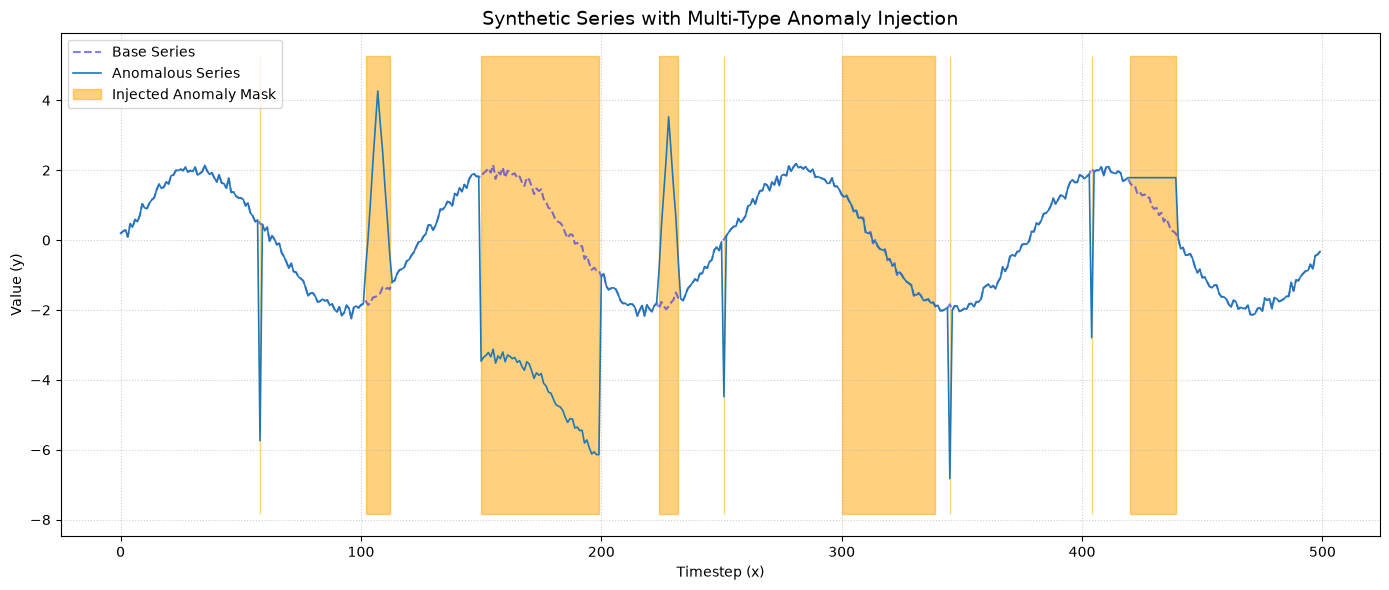

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot raw vs anomalous series
ax.plot(
    sinusoidal_series.x.numpy(),
    sinusoidal_series.y.numpy(),
    label="Base Series",
    color="blue",
    alpha=0.5,
    linestyle="--",
)
ax.plot(
    anomalous_series.x.numpy(),
    anomalous_series.y.numpy(),
    label="Anomalous Series",
    color="tab:blue",
    linewidth=1.2,
)

# Highlight anomalous regions based on boolean mask
anom_mask = anomalous_series.is_anomaly.numpy()
x_vals = anomalous_series.x.numpy()

ax.fill_between(
    x_vals,
    anomalous_series.y.numpy().min() - 1,
    anomalous_series.y.numpy().max() + 1,
    where=anom_mask,
    color="orange",
    alpha=0.5,
    label="Injected Anomaly Mask",
)

ax.set_title("Synthetic Series with Multi-Type Anomaly Injection", fontsize=14)
ax.set_xlabel("Timestep (x)")
ax.set_ylabel("Value (y)")
ax.legend(loc="upper left")
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()